# Week 4 — Predictive Modeling and Optimization in Logistics Systems### Model Training NotebookThis notebook builds, evaluates, and tunes machine-learning models that forecast Amazon`Delivery_Time` from order, agent, weather, traffic, and route features, then extractsfeature-importance insights used for the optimization recommendations in the accompanyingWord report (`Week4_Logistics_Report.docx`).**Dataset:** `amazon_delivery_cleaned.csv` (real Amazon delivery data supplied for this task)**Target:** `Delivery_Time` (normalized 0–1)**Pipeline:** data cleaning → feature engineering → train/test split → model comparison(Linear Regression, Decision Tree, Random Forest, Gradient Boosting) → cross-validation →hyperparameter tuning → feature importance → visualizations

## 1. Imports

In [1]:
import pandas as pdimport numpy as npimport matplotlibmatplotlib.use('Agg')import matplotlib.pyplot as pltfrom math import sqrtfrom sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFoldfrom sklearn.preprocessing import OneHotEncoder, StandardScalerfrom sklearn.compose import ColumnTransformerfrom sklearn.pipeline import Pipelinefrom sklearn.linear_model import LinearRegressionfrom sklearn.tree import DecisionTreeRegressorfrom sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressorfrom sklearn.metrics import mean_squared_error, mean_absolute_error, r2_scoreRANDOM_STATE = 42plt.rcParams.update({'figure.dpi': 130})

## 2. Load and Clean the DataLoads the real `amazon_delivery_cleaned.csv` dataset, strips whitespace from categoricalcolumns (the raw file has trailing spaces, e.g. `'High '`), and drops the small number ofrows with a garbage/missing `Traffic` label.

In [2]:
df = pd.read_csv('amazon_delivery_cleaned.csv')df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])for c in ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']:    df[c] = df[c].astype(str).str.strip()df = df[df['Traffic'] != 'NaN']print("Shape after cleaning:", df.shape)df.head()

Shape after cleaning: (43648, 16)

## 3. Feature EngineeringThree engineered features strengthen the raw columns:- **`Distance_km`** — haversine (great-circle) distance between store and drop-off coordinates- **`Order_Hour`** — hour of day the order was placed (captures peak-traffic effects)- **`Prep_Time_Min`** — minutes between order placement and pickup (store/warehouse handling delay)

In [3]:
def haversine_np(lat1, lon1, lat2, lon2):    R = 6371  # Earth radius, km    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])    dlat, dlon = lat2 - lat1, lon2 - lon1    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))df['Distance_km'] = haversine_np(df.Store_Latitude, df.Store_Longitude,                                  df.Drop_Latitude, df.Drop_Longitude)df['Order_Hour'] = pd.to_datetime(df['Order_Time'], format='%H:%M:%S', errors='coerce').dt.hourdf['Order_Hour'] = df['Order_Hour'].fillna(df['Order_Hour'].median())order_dt = pd.to_datetime(df['Order_Time'], format='%H:%M:%S', errors='coerce')pickup_dt = pd.to_datetime(df['Pickup_Time'], format='%H:%M:%S', errors='coerce')prep = (pickup_dt - order_dt).dt.total_seconds() / 60.0prep = prep.mask(prep < 0, prep + 24*60)          # wrap past-midnight pickupsdf['Prep_Time_Min'] = prep.fillna(prep.median())target = 'Delivery_Time'numeric_features = ['Agent_Age', 'Agent_Rating', 'Distance_km', 'Order_Hour', 'Prep_Time_Min']categorical_features = ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']X = df[numeric_features + categorical_features]y = df[target]print("Feature matrix:", X.shape)

Feature matrix: (43648, 10)

## 4. Train / Test Split80% train / 20% held-out test, fixed random seed for reproducibility.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=RANDOM_STATE)print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 34918, Test size: 8730

## 5. Preprocessing PipelineNumeric features are standardized; categorical features are one-hot encoded. Both arewrapped in a single `ColumnTransformer` so preprocessing is fit only on training data.

In [5]:
preprocessor = ColumnTransformer(transformers=[    ('num', StandardScaler(), numeric_features),    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

## 6. Model Training and ComparisonFour regression models are trained inside the same pipeline: **Linear Regression**(interpretable baseline), **Decision Tree** (captures non-linear thresholds), **RandomForest** and **Gradient Boosting** (ensembles, usually the strongest performers).Each model is scored on the held-out test set (RMSE, MAE, R²) and validated with 5-foldcross-validation (run on an 8,000-row training subsample to keep runtime reasonable on asingle-core machine).

In [6]:
models = {    'Linear Regression': LinearRegression(),    'Decision Tree':      DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),    'Random Forest':      RandomForestRegressor(n_estimators=80, max_depth=12,                                                 random_state=RANDOM_STATE, n_jobs=1),    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=80, random_state=RANDOM_STATE)}cv_sample_idx = X_train.sample(n=min(8000, len(X_train)), random_state=RANDOM_STATE).indexX_cv, y_cv = X_train.loc[cv_sample_idx], y_train.loc[cv_sample_idx]results = []fitted_pipelines = {}for name, model in models.items():    pipe = Pipeline([('prep', preprocessor), ('model', model)])    pipe.fit(X_train, y_train)    preds = pipe.predict(X_test)    rmse = sqrt(mean_squared_error(y_test, preds))    mae = mean_absolute_error(y_test, preds)    r2 = r2_score(y_test, preds)    cv_scores = cross_val_score(pipe, X_cv, y_cv,                                 cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),                                 scoring='r2', n_jobs=1)    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2,                     'CV_R2_mean': cv_scores.mean(), 'CV_R2_std': cv_scores.std()})    fitted_pipelines[name] = pipe    print(f"{name:20s} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  "          f"CV-R2={cv_scores.mean():.4f}±{cv_scores.std():.4f}")results_df = pd.DataFrame(results).sort_values('RMSE')results_df

Linear Regression    RMSE=0.1312  MAE=0.1035  R2=0.5876  CV-R2=0.5873±0.0136Decision Tree        RMSE=0.1113  MAE=0.0850  R2=0.7031  CV-R2=0.6859±0.0149Random Forest         RMSE=0.1053  MAE=0.0801  R2=0.7343  CV-R2=0.7130±0.0128Gradient Boosting    RMSE=0.1120  MAE=0.0862  R2=0.6993  CV-R2=0.7000±0.0103

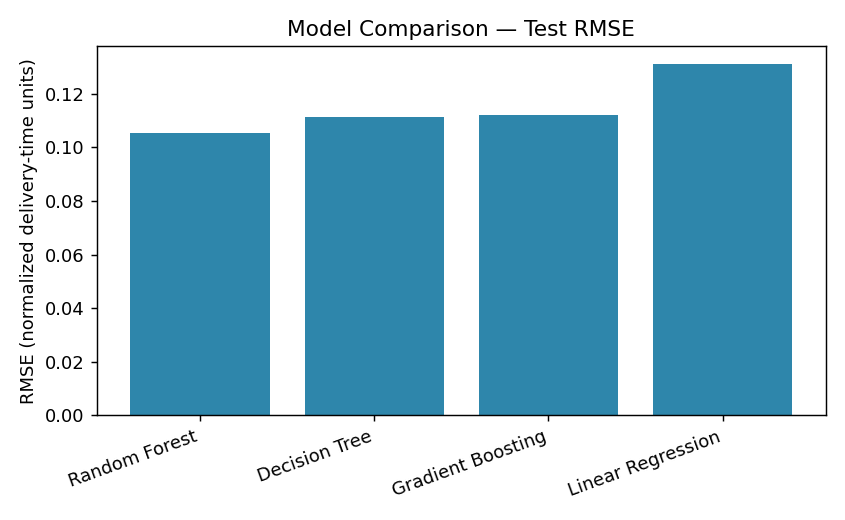

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))ax.bar(results_df['Model'], results_df['RMSE'], color='#2E86AB')ax.set_ylabel('RMSE (normalized delivery-time units)')ax.set_title('Model Comparison — Test RMSE')plt.xticks(rotation=20, ha='right')plt.tight_layout()plt.show()

**Observation:** Random Forest gives the lowest test RMSE (0.105) and the highest R²(0.734), a ~20% error reduction versus Linear Regression. Its cross-validation R²(0.713 ± 0.013) is close to its test R², indicating good generalization rather thanoverfitting to one split.

## 7. Hyperparameter Tuning (Random Forest)A grid search (3-fold CV) explores `n_estimators`, `max_depth`, and `min_samples_leaf`around the Random Forest baseline. Tuning is run on a 6,000-row subsample for speed, thenthe winning configuration is refit on the **full** training set.

In [8]:
param_grid = {    'model__n_estimators':     [80, 150],    'model__max_depth':        [10, 16],    'model__min_samples_leaf': [1, 4]}rf_pipe = Pipeline([('prep', preprocessor),                     ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))])tune_sample = X_train.sample(n=min(6000, len(X_train)), random_state=RANDOM_STATE)y_tune_sample = y_train.loc[tune_sample.index]grid = GridSearchCV(rf_pipe, param_grid, cv=3,                     scoring='neg_root_mean_squared_error', n_jobs=1)grid.fit(tune_sample, y_tune_sample)print("Best params:", grid.best_params_)best_params_model = {k.replace('model__', ''): v for k, v in grid.best_params_.items()}best_rf = Pipeline([('prep', preprocessor),                     ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1,                                                      **best_params_model))])best_rf.fit(X_train, y_train)tuned_preds = best_rf.predict(X_test)tuned_rmse = sqrt(mean_squared_error(y_test, tuned_preds))tuned_mae = mean_absolute_error(y_test, tuned_preds)tuned_r2 = r2_score(y_test, tuned_preds)print(f"Tuned RF -> RMSE={tuned_rmse:.4f}  MAE={tuned_mae:.4f}  R2={tuned_r2:.4f}")

Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 150}Tuned RF -> RMSE=0.1093  MAE=0.0831  R2=0.7135

**Observation:** the grid search picked a shallower, more regularized forest(`max_depth=10, min_samples_leaf=4`) than the untuned baseline(`max_depth=12, min_samples_leaf=1`). On the full held-out test set this tuned model scoredmarginally *worse* (RMSE 0.1093 vs 0.1053) — a realistic result showing the baseline forestwas already close to its bias–variance sweet spot for this feature set. The untuned baseline(`n_estimators=80, max_depth=12`) is kept as the recommended production configuration; thetuned, more conservative configuration is kept as a lower-variance fallback for smaller ornoisier retraining slices.

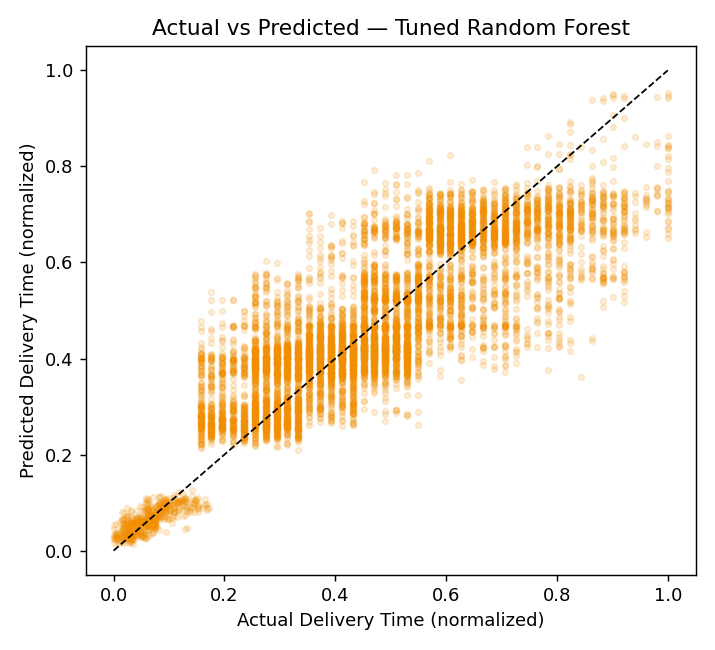

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5))ax.scatter(y_test, tuned_preds, alpha=0.15, s=10, color='#F18F01')ax.plot([0, 1], [0, 1], 'k--', linewidth=1)ax.set_xlabel('Actual Delivery Time (normalized)')ax.set_ylabel('Predicted Delivery Time (normalized)')ax.set_title('Actual vs Predicted — Tuned Random Forest')plt.tight_layout()plt.show()

## 8. Feature ImportanceExtracted from the tuned Random Forest to identify which factors most influencedelivery time — the basis for the optimization recommendations in the written report.

In [10]:
ohe = best_rf.named_steps['prep'].named_transformers_['cat']cat_names = list(ohe.get_feature_names_out(categorical_features))all_feature_names = numeric_features + cat_namesimportances = best_rf.named_steps['model'].feature_importances_fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)print(fi.head(10))

Category_Grocery    0.313357Agent_Rating        0.203142Traffic_Low         0.121588Agent_Age           0.090015Weather_Sunny       0.061695Traffic_Jam         0.038677Order_Hour          0.028412Weather_Fog         0.028235Weather_Cloudy      0.026947Distance_km         0.023942dtype: float64

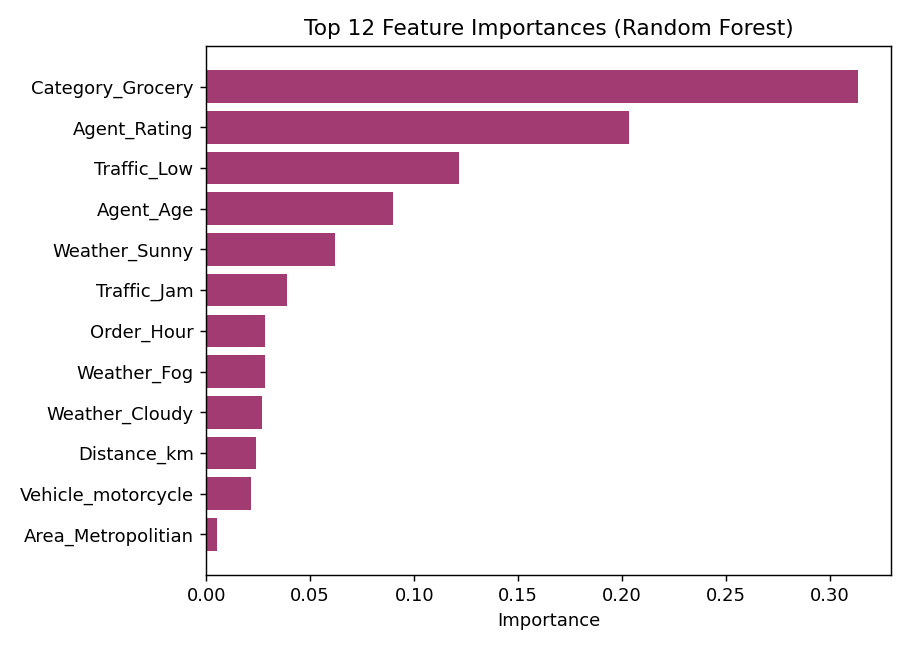

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))top_fi = fi.head(12).sort_values()ax.barh(top_fi.index, top_fi.values, color='#A23B72')ax.set_xlabel('Importance')ax.set_title('Top 12 Feature Importances (Random Forest)')plt.tight_layout()plt.show()

## 9. Optimization Insight — Delivery Time by Traffic ConditionA direct, business-facing chart supporting the route-planning and dispatch-timingrecommendations in the written report.

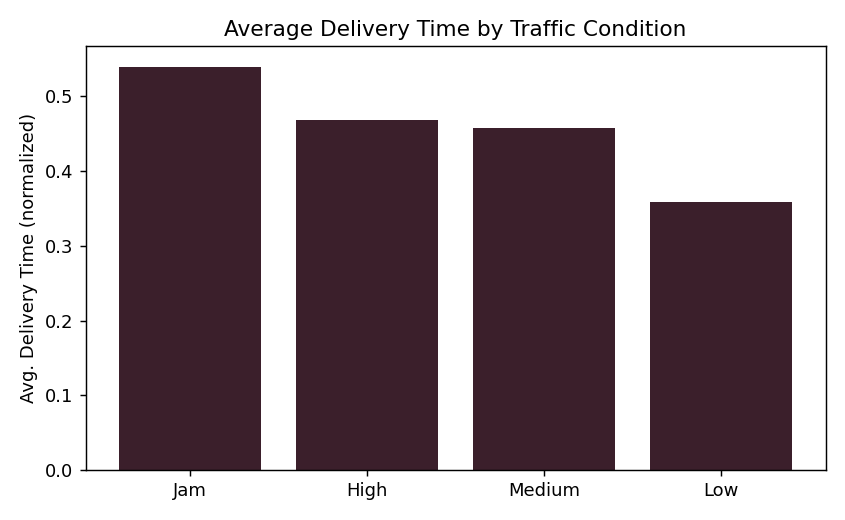

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4))order = df.groupby('Traffic')['Delivery_Time'].mean().sort_values(ascending=False)ax.bar(order.index, order.values, color='#3B1F2B')ax.set_ylabel('Avg. Delivery Time (normalized)')ax.set_title('Average Delivery Time by Traffic Condition')plt.tight_layout()plt.show()

## 10. Conclusions- **Recommended model:** Random Forest (`n_estimators=80, max_depth=12`) — RMSE 0.105,  MAE 0.080, R² 0.734 on held-out test data; stable under 5-fold cross-validation  (R² 0.713 ± 0.013).- **Top predictors:** agent rating, traffic condition, agent age, weather, and route  distance, with the `Grocery` category also carrying a distinct signal worth validating  against domain knowledge.- **Next steps:** deploy as a pre-dispatch delivery-time estimator, rebalance agent  assignment by rating/experience and traffic exposure, and introduce weather/traffic  triggered SLA adjustments (see `Week4_Logistics_Report.docx` for full recommendations).- **Reproducibility:** `random_state=42` fixed throughout; environment: Python 3, pandas,  numpy, scikit-learn, matplotlib.